In [1]:
#  Bhopal AQI Prediction — Bayesian Hyperparameter Optimization
#  Uses: Optuna (pip install optuna)
#  Builds on: same data as 04_improved_model_training

In [2]:
#  INSTALL & IMPORTS
# 
# pip install optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs

import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style("whitegrid")
print("✅ All imports successful  (Optuna version:", optuna.__version__, ")")
print("=" * 65)
print("  BAYESIAN-OPTIMIZED XGBOOST")
print("  Optuna TPE search → best hyperparams → retrain → evaluate")
print("=" * 65)

✅ All imports successful  (Optuna version: 4.8.0 )
  BAYESIAN-OPTIMIZED XGBOOST
  Optuna TPE search → best hyperparams → retrain → evaluate


In [3]:
#  LOAD DATA
train_path = r"D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv"
test_path  = r"D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv"

train = pd.read_csv(train_path, parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(test_path,  parse_dates=['datetime'], index_col='datetime')

print(f"✅ Train: {train.shape}  |  {train.index.min()} → {train.index.max()}")
print(f"✅ Test:  {test.shape}   |  {test.index.min()}  → {test.index.max()}")

✅ Train: (13632, 184)  |  2024-01-01 00:00:00 → 2025-07-21 23:00:00
✅ Test:  (3408, 184)   |  2025-07-22 00:00:00  → 2025-12-10 23:00:00


In [4]:
# FEATURE PREPARATION
TIME_LEAKERS = ['year', 'month', 'day', 'day_of_month', 'week_of_year']

SAFE_TIME = ['hour_sin','hour_cos','month_sin','month_cos',
             'hour_of_day','day_of_week','is_weekend',
             'is_night','is_morning_rush','is_evening_rush','season']

WEATHER = ['temp','humidity','windspeed','winddir','precip',
           'cloudcover','visibility','sealevelpressure','uvindex']

lag_feats     = [c for c in train.columns if '_lag_' in c]
rolling_feats = [c for c in train.columns if '_roll_' in c]

all_features = list(set(SAFE_TIME + WEATHER + lag_feats + rolling_feats))
all_features = [f for f in all_features if f in train.columns]
all_features = [f for f in all_features if f not in TIME_LEAKERS]

TARGETS = ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills']

X_train = train[all_features]
X_test  = test[all_features]
y_train = train[TARGETS]
y_test  = test[TARGETS]

print(f"\n✅ Features: {len(all_features)}  |  Targets: {TARGETS}")
print(f"✅ X_train: {X_train.shape}  |  X_test: {X_test.shape}")


✅ Features: 146  |  Targets: ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills']
✅ X_train: (13632, 146)  |  X_test: (3408, 146)


In [5]:
#  BASELINE: MANUAL XGBOOST (for comparison)
print("\nTRAINING BASELINE MANUAL XGBOOST (your existing model)")

manual_results = {}
for target in TARGETS:
    baseline = xgb.XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8,    colsample_bytree=0.8,
        reg_alpha=0.5,    reg_lambda=1.0,
        random_state=42,  n_jobs=-1, verbosity=0
    )
    baseline.fit(X_train, y_train[target])
    y_pred = baseline.predict(X_test)
    r2  = r2_score(y_test[target], y_pred)
    mae = mean_absolute_error(y_test[target], y_pred)
    manual_results[target] = {'model': baseline, 'r2': r2, 'mae': mae}
    print(f"  {target:<30} Test R²: {r2:.4f}  |  MAE: {mae:.2f}")

print("\n✅ Baseline recorded — Optuna will try to beat these scores")


TRAINING BASELINE MANUAL XGBOOST (your existing model)
  PM25_Idgah_Hills               Test R²: 0.9911  |  MAE: 0.52
  PM10_Idgah_Hills               Test R²: 0.9962  |  MAE: 1.25
  NO2_Idgah_Hills                Test R²: 0.9885  |  MAE: 0.31

✅ Baseline recorded — Optuna will try to beat these scores


In [6]:
#  OPTUNA OBJECTIVE FUNCTION
"""
HOW BAYESIAN OPTIMIZATION WORKS:
──────────────────────────────────
Unlike Grid Search (tries all combos) or Random Search (random),
Bayesian Optimization LEARNS from past trials:

Trial 1: Random params → score 0.55
Trial 2: Adjusted based on Trial 1 → score 0.58
Trial 3: Further adjusted → score 0.61
...
Trial 100: Converges on best known params → score 0.68

The algorithm is Tree-structured Parzen Estimator (TPE):
  - Builds a probabilistic model of which param regions give
    high scores
  - Samples new trials from high-probability regions
  - Result: much faster than grid search for the same quality

SEARCH SPACE (what Optuna tunes):
  n_estimators   : 100  – 500   (how many trees)
  max_depth      : 3   – 8     (tree complexity)
  learning_rate  : 0.01 – 0.30  (step size)
  subsample      : 0.5  – 1.0   (row sampling)
  colsample_bytree: 0.5 – 1.0   (column sampling)
  reg_alpha      : 0.0  – 10.0  (L1 penalty)
  reg_lambda     : 0.0  – 10.0  (L2 penalty)
  min_child_weight: 1   – 10    (leaf min samples)
  gamma          : 0.0  – 1.0   (split minimum gain)
"""

N_TRIALS = 50    # Set to 100 for best results, 50 for faster run (~10 min)
N_CV_SPLITS = 5  # TimeSeriesSplit folds

def make_objective(X_tr, y_tr, n_splits=N_CV_SPLITS):
    """
    Returns an Optuna objective function for a given target.
    Optuna MINIMIZES by default — we return -R² so it maximizes R².

    FIX — n_jobs rules inside this function:
    ─────────────────────────────────────────
    cross_val_score(n_jobs=-1) spawns parallel worker processes.
    Each worker contains an XGBRegressor that also wants n_jobs=-1.
    Two levels of parallelism fighting → ValueError / deadlock.

    Solution:
      • XGBRegressor  → n_jobs=1   (no internal threading)
      • cross_val_score → n_jobs=1  (no external forking either)
      • Optuna itself handles parallelism at the TRIAL level if needed.
    Speed is still fine: Optuna runs many sequential trials, each
    fast because XGBoost's hist tree method is already vectorised.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int(  'n_estimators',      100, 500),
            'max_depth'        : trial.suggest_int(  'max_depth',          3,   8),
            'learning_rate'    : trial.suggest_float('learning_rate',      0.01, 0.30, log=True),
            'subsample'        : trial.suggest_float('subsample',          0.5,  1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree',   0.5,  1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha',          0.0, 10.0),
            'reg_lambda'       : trial.suggest_float('reg_lambda',         0.0, 10.0),
            'min_child_weight' : trial.suggest_int(  'min_child_weight',   1,   10),
            'gamma'            : trial.suggest_float('gamma',              0.0,  1.0),
            'random_state'     : 42,
            'n_jobs'           : 1,        # ← FIX: 1 inside objective (not -1)
            'verbosity'        : 0,
            'tree_method'      : 'hist',   # keeps it fast even with n_jobs=1
        }
        model  = xgb.XGBRegressor(**params)
        scores = cross_val_score(
            model, X_tr, y_tr,
            cv=tscv, scoring='r2',
            n_jobs=1               # ← FIX: 1 here too (not -1)
        )
        return -scores.mean()      # negate because Optuna minimizes

    return objective

In [7]:
#  RUN OPTUNA FOR EACH TARGET
best_params_all = {}
bayes_results   = []
best_models     = {}

print(f"RUNNING BAYESIAN OPTIMIZATION ({N_TRIALS} trials × {len(TARGETS)} targets)")
print(f"   Each trial uses {N_CV_SPLITS}-fold TimeSeriesSplit CV")
print(f"   Estimated time: ~{N_TRIALS * len(TARGETS) // 6} minutes")
print()

for target in TARGETS:
    print(f"  Optimizing: {target}")
    print(f"  {'─'*50}")

    study = optuna.create_study(
        direction='minimize',      # minimizing -R²  =  maximizing R²
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
    )

    study.optimize(
        make_objective(X_train, y_train[target]),
        n_trials=N_TRIALS,
        show_progress_bar=True   # shows a tqdm bar per target
    )

    best_p    = study.best_params
    best_cv   = -study.best_value   # flip back to positive R²
    best_params_all[target] = best_p

    # ── Print best found params ──
    print(f"\n  Best CV R²   : {best_cv:.4f}")
    print(f"  Best params  :")
    for k, v in best_p.items():
        print(f"    {k:<22} = {v}")

    # ── Retrain on FULL training set with best params ──
    final_model = xgb.XGBRegressor(
        **best_p, random_state=42, n_jobs=-1, verbosity=0
    )
    final_model.fit(X_train, y_train[target])
    best_models[target] = final_model

    # ── Evaluate on test set ──
    y_pred_train = final_model.predict(X_train)
    y_pred_test  = final_model.predict(X_test)

    r2_tr  = r2_score(y_train[target], y_pred_train)
    r2_te  = r2_score(y_test[target],  y_pred_test)
    mae_te = mean_absolute_error(y_test[target], y_pred_test)
    rmse   = np.sqrt(mean_squared_error(y_test[target], y_pred_test))
    manual_r2 = manual_results[target]['r2']

    bayes_results.append({
        'Target'       : target,
        'Manual_R2'    : manual_r2,
        'Bayes_CV_R2'  : best_cv,
        'Bayes_Train_R2': r2_tr,
        'Bayes_Test_R2': r2_te,
        'Bayes_MAE'    : mae_te,
        'Bayes_RMSE'   : rmse,
        'Improvement'  : r2_te - manual_r2,
        'Best_Params'  : best_p,
        'Predictions'  : y_pred_test,
        'Study'        : study,
    })

    print(f"\n  Manual XGBoost R²   : {manual_r2:.4f}")
    print(f"  Bayes  XGBoost R²   : {r2_te:.4f}  ← improvement: {r2_te-manual_r2:+.4f}")
    print(f"  MAE: {mae_te:.2f}  |  RMSE: {rmse:.2f}")
    print()

print("✅ Bayesian optimization complete for all targets")

RUNNING BAYESIAN OPTIMIZATION (50 trials × 3 targets)
   Each trial uses 5-fold TimeSeriesSplit CV
   Estimated time: ~25 minutes

  Optimizing: PM25_Idgah_Hills
  ──────────────────────────────────────────────────


Best trial: 47. Best value: -0.992203: 100%|██████████| 50/50 [56:05<00:00, 67.30s/it]   



  Best CV R²   : 0.9922
  Best params  :
    n_estimators           = 500
    max_depth              = 8
    learning_rate          = 0.03662295617356871
    subsample              = 0.8873159110859693
    colsample_bytree       = 0.9044048395280783
    reg_alpha              = 0.24293970534906917
    reg_lambda             = 1.5098219949682647
    min_child_weight       = 10
    gamma                  = 0.2560937368707008

  Manual XGBoost R²   : 0.9911
  Bayes  XGBoost R²   : 0.9940  ← improvement: +0.0030
  MAE: 0.36  |  RMSE: 0.95

  Optimizing: PM10_Idgah_Hills
  ──────────────────────────────────────────────────


Best trial: 42. Best value: -0.987626: 100%|██████████| 50/50 [16:14<00:00, 19.48s/it]



  Best CV R²   : 0.9876
  Best params  :
    n_estimators           = 270
    max_depth              = 4
    learning_rate          = 0.18990475548967578
    subsample              = 0.8887894990453714
    colsample_bytree       = 0.9727402827202618
    reg_alpha              = 1.57865545449854
    reg_lambda             = 0.10936363283230097
    min_child_weight       = 10
    gamma                  = 0.514363645805956

  Manual XGBoost R²   : 0.9962
  Bayes  XGBoost R²   : 0.9961  ← improvement: -0.0000
  MAE: 1.31  |  RMSE: 2.65

  Optimizing: NO2_Idgah_Hills
  ──────────────────────────────────────────────────


Best trial: 13. Best value: -0.98318: 100%|██████████| 50/50 [10:03<00:00, 12.06s/it] 



  Best CV R²   : 0.9832
  Best params  :
    n_estimators           = 499
    max_depth              = 3
    learning_rate          = 0.16404322580340452
    subsample              = 0.9996812193207756
    colsample_bytree       = 0.7783018090268713
    reg_alpha              = 7.171574490062914
    reg_lambda             = 2.4183403134408943
    min_child_weight       = 5
    gamma                  = 0.6693201910118401

  Manual XGBoost R²   : 0.9885
  Bayes  XGBoost R²   : 0.9917  ← improvement: +0.0032
  MAE: 0.27  |  RMSE: 0.59

✅ Bayesian optimization complete for all targets


In [8]:
#  RESULTS TABLE
results_df = pd.DataFrame(bayes_results)
print("\nFINAL RESULTS: Manual XGBoost vs Bayesian-Optimized XGBoost")
print("=" * 75)
show_cols = ['Target','Manual_R2','Bayes_Test_R2','Improvement','Bayes_MAE','Bayes_RMSE']
print(results_df[show_cols].round(4).to_string(index=False))
print(f"\nAverage improvement over manual tuning: {results_df['Improvement'].mean():+.4f} R²")
print(f"Average Bayesian Test R²: {results_df['Bayes_Test_R2'].mean():.4f}")


FINAL RESULTS: Manual XGBoost vs Bayesian-Optimized XGBoost
          Target  Manual_R2  Bayes_Test_R2  Improvement  Bayes_MAE  Bayes_RMSE
PM25_Idgah_Hills     0.9911         0.9940       0.0030     0.3632      0.9522
PM10_Idgah_Hills     0.9962         0.9961      -0.0000     1.3074      2.6469
 NO2_Idgah_Hills     0.9885         0.9917       0.0032     0.2693      0.5871

Average improvement over manual tuning: +0.0020 R²
Average Bayesian Test R²: 0.9939


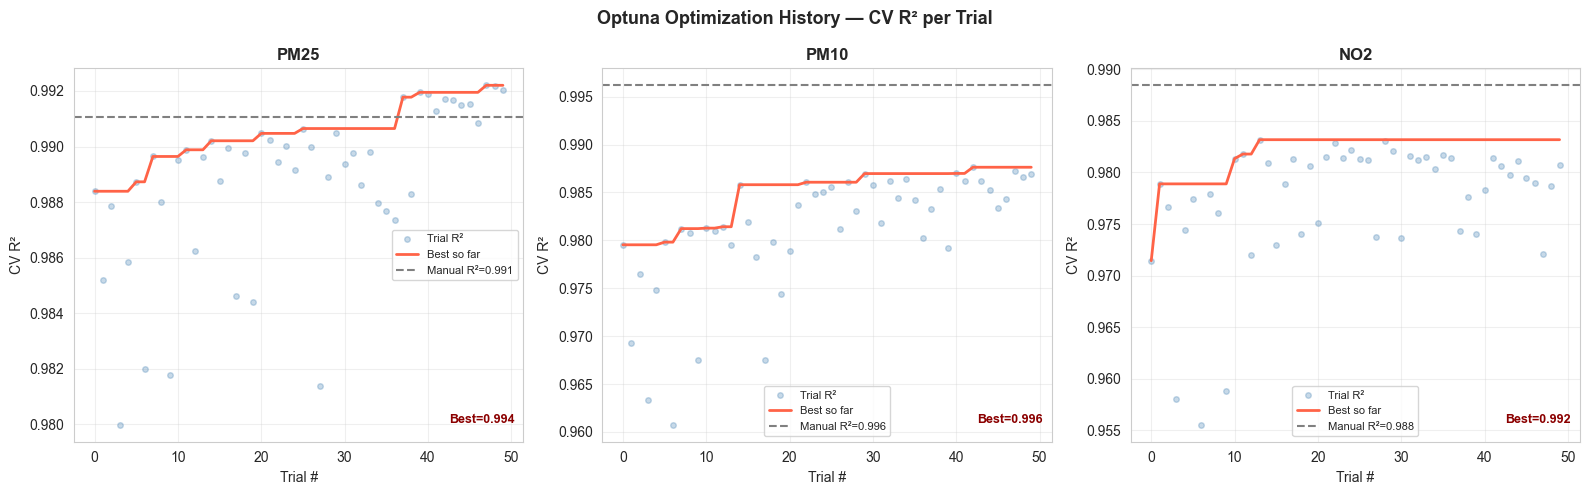

✅ Saved: optuna_history.png


In [9]:
#  VISUALIZATION: OPTIMIZATION HISTORY
fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 5))

for idx, result in enumerate(bayes_results):
    target = result['Target']
    study  = result['Study']
    ax     = axes[idx]

    # Best value at each trial (cumulative best)
    trial_values = [-t.value for t in study.trials]  # flip back to R²
    best_so_far  = [max(trial_values[:i+1]) for i in range(len(trial_values))]

    ax.plot(trial_values, 'o', color='steelblue', alpha=0.3, markersize=4, label='Trial R²')
    ax.plot(best_so_far,  '-', color='tomato',    lw=2,      label='Best so far')
    ax.axhline(result['Manual_R2'], color='gray', linestyle='--', lw=1.5, label=f"Manual R²={result['Manual_R2']:.3f}")
    ax.set_title(target.replace('_Idgah_Hills','').replace('_TT_Nagar','_TT'), fontweight='bold')
    ax.set_xlabel('Trial #'); ax.set_ylabel('CV R²')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.05, f"Best={result['Bayes_Test_R2']:.3f}", transform=ax.transAxes,
            ha='right', fontsize=9, color='darkred', fontweight='bold')

plt.suptitle('Optuna Optimization History — CV R² per Trial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: optuna_history.png")

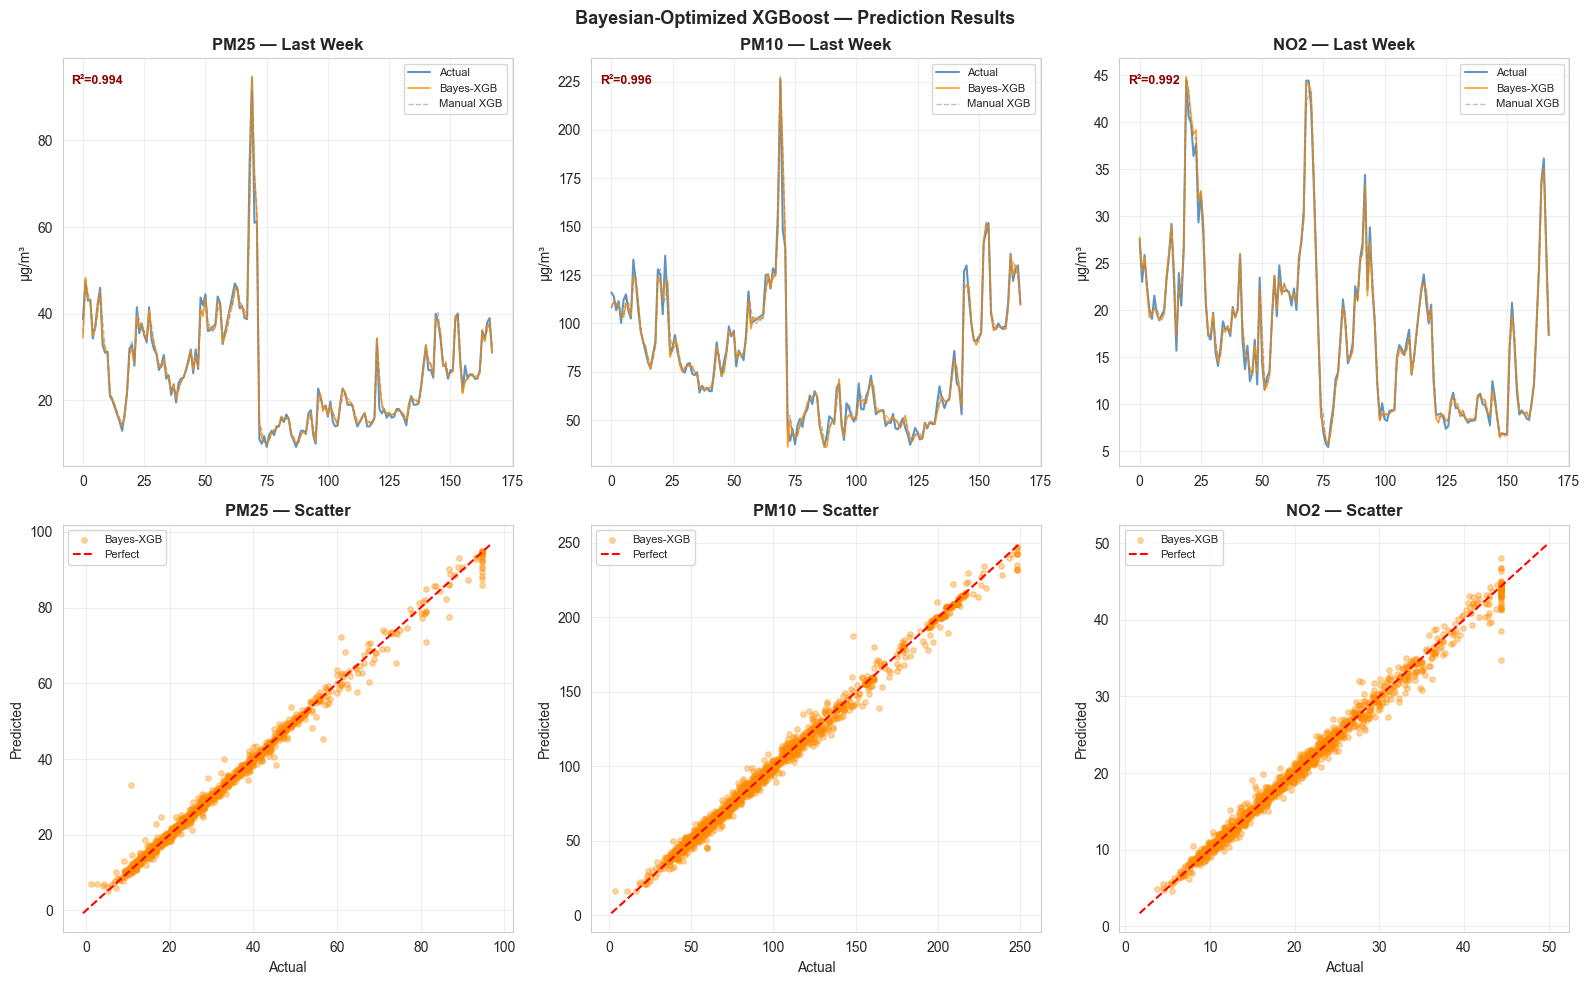

✅ Saved: bayes_predictions.png


In [10]:
# VISUALIZATION: PREDICTIONS vs ACTUAL
fig, axes = plt.subplots(2, len(TARGETS), figsize=(16, 10))

for idx, result in enumerate(bayes_results):
    target = result['Target']
    y_te   = y_test[target].values
    y_pred = result['Predictions']
    short  = target.replace('_Idgah_Hills','').replace('_TT_Nagar','_TT')

    # Time series
    ax = axes[0, idx]
    n  = min(168, len(y_te))
    ax.plot(y_te[-n:],   color='steelblue', lw=1.5, alpha=0.85, label='Actual')
    ax.plot(y_pred[-n:], color='darkorange', lw=1.2, alpha=0.85, label='Bayes-XGB')
    ax.plot(manual_results[target]['model'].predict(X_test)[-n:],
            color='gray', lw=1.0, alpha=0.5, linestyle='--', label='Manual XGB')
    ax.set_title(f'{short} — Last Week', fontweight='bold')
    ax.set_ylabel('µg/m³'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.96, f"R²={result['Bayes_Test_R2']:.3f}", transform=ax.transAxes,
            fontsize=9, va='top', fontweight='bold', color='darkred')

    # Scatter
    ax2 = axes[1, idx]
    ax2.scatter(y_te, y_pred, alpha=0.35, s=15, color='darkorange', label='Bayes-XGB')
    lim = [min(y_te.min(), y_pred.min()) - 2, max(y_te.max(), y_pred.max()) + 2]
    ax2.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
    ax2.set_xlabel('Actual'); ax2.set_ylabel('Predicted')
    ax2.set_title(f'{short} — Scatter', fontweight='bold')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Bayesian-Optimized XGBoost — Prediction Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bayes_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: bayes_predictions.png")

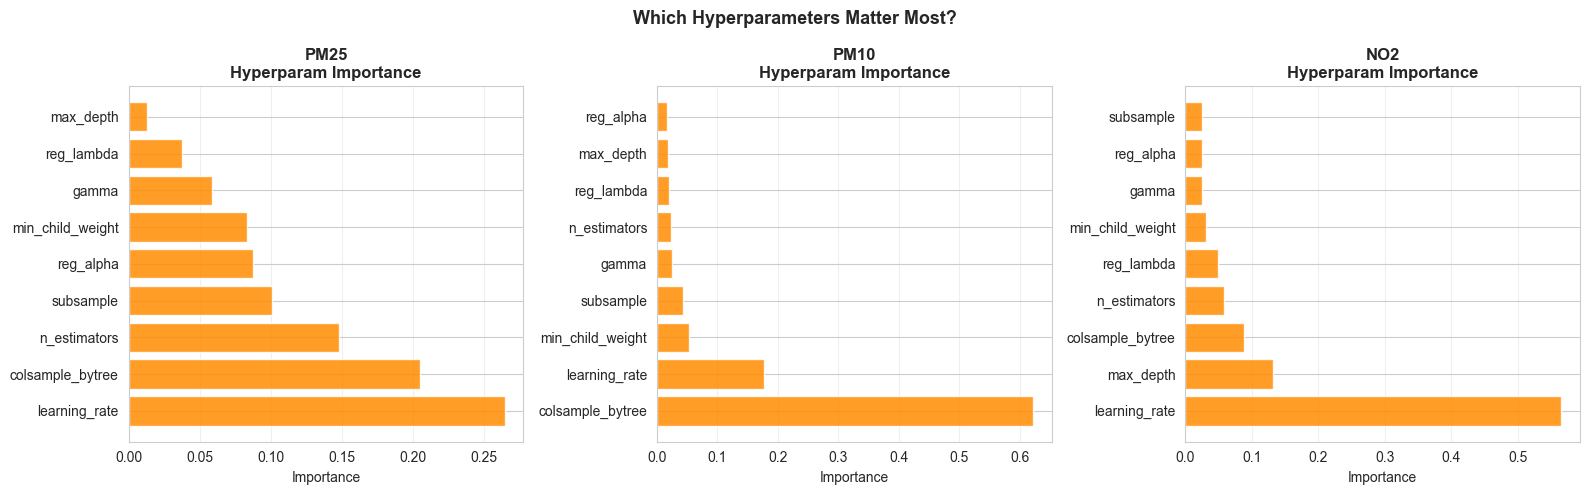

✅ Saved: hyperparam_importance.png


In [11]:
#  HYPERPARAMETER IMPORTANCE
fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 5))

for idx, result in enumerate(bayes_results):
    target = result['Target']
    study  = result['Study']
    ax     = axes[idx]
    short  = target.replace('_Idgah_Hills','').replace('_TT_Nagar','_TT')

    try:
        importance = optuna.importance.get_param_importances(study)
        names  = list(importance.keys())
        values = list(importance.values())
        ax.barh(names, values, color='darkorange', alpha=0.85)
        ax.set_xlabel('Importance')
        ax.set_title(f'{short}\nHyperparam Importance', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
    except Exception:
        ax.text(0.5, 0.5, 'Need ≥20 trials\nfor importance', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{short}\nHyperparam Importance', fontweight='bold')

plt.suptitle('Which Hyperparameters Matter Most?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparam_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: hyperparam_importance.png")

In [12]:
#  BEST PARAMS SUMMARY (PRINT CLEAN)
print("\nBEST HYPERPARAMETERS FOUND BY OPTUNA")
print("=" * 65)
for target, params in best_params_all.items():
    print(f"\n  {target}:")
    for k, v in params.items():
        if isinstance(v, float):
            print(f"    {k:<22} = {v:.5f}")
        else:
            print(f"    {k:<22} = {v}")


BEST HYPERPARAMETERS FOUND BY OPTUNA

  PM25_Idgah_Hills:
    n_estimators           = 500
    max_depth              = 8
    learning_rate          = 0.03662
    subsample              = 0.88732
    colsample_bytree       = 0.90440
    reg_alpha              = 0.24294
    reg_lambda             = 1.50982
    min_child_weight       = 10
    gamma                  = 0.25609

  PM10_Idgah_Hills:
    n_estimators           = 270
    max_depth              = 4
    learning_rate          = 0.18990
    subsample              = 0.88879
    colsample_bytree       = 0.97274
    reg_alpha              = 1.57866
    reg_lambda             = 0.10936
    min_child_weight       = 10
    gamma                  = 0.51436

  NO2_Idgah_Hills:
    n_estimators           = 499
    max_depth              = 3
    learning_rate          = 0.16404
    subsample              = 0.99968
    colsample_bytree       = 0.77830
    reg_alpha              = 7.17157
    reg_lambda             = 2.41834
    min_child_w

In [13]:
#  SAVE MODELS & BEST PARAMS
save_dir = Path(r"D:\bhopal-pollutant-prediction\models_bayes")
save_dir.mkdir(parents=True, exist_ok=True)

import json

for target in TARGETS:
    safe = target.replace('.','_')
    joblib.dump(best_models[target], save_dir / f"bayes_xgb_{safe}.joblib")

    # Save best params as JSON for reference
    params_to_save = {k: float(v) if isinstance(v, (np.floating, float)) else int(v)
                      for k, v in best_params_all[target].items()}
    with open(save_dir / f"best_params_{safe}.json", 'w') as f:
        json.dump(params_to_save, f, indent=2)

    print(f"✅ Saved: bayes_xgb_{safe}.joblib + best_params_{safe}.json")

# Save results CSV
results_df.drop(columns=['Best_Params','Predictions','Study']).to_csv(
    save_dir / "bayes_results.csv", index=False)
print(f"\n✅ All models saved in: {save_dir}")
print("\n✅ BAYESIAN-OPTIMIZED XGBOOST COMPLETE!")

✅ Saved: bayes_xgb_PM25_Idgah_Hills.joblib + best_params_PM25_Idgah_Hills.json
✅ Saved: bayes_xgb_PM10_Idgah_Hills.joblib + best_params_PM10_Idgah_Hills.json
✅ Saved: bayes_xgb_NO2_Idgah_Hills.joblib + best_params_NO2_Idgah_Hills.json

✅ All models saved in: D:\bhopal-pollutant-prediction\models_bayes

✅ BAYESIAN-OPTIMIZED XGBOOST COMPLETE!


In [14]:
#  HOW TO USE SAVED MODELS
print("""
═══════════════════════════════════════════════════════════
  HOW TO LOAD AND USE THE BAYESIAN-OPTIMIZED MODEL LATER:
═══════════════════════════════════════════════════════════

import joblib, json

target = 'PM25_Idgah_Hills'
safe   = target.replace('.','_')
base_dir = r"D:/bhopal-pollutant-prediction/models_bayes"

# Load model
model = joblib.load(f"{base_dir}/bayes_xgb_{safe}.joblib")

# (Optional) check what params were used
with open(f"{base_dir}/best_params_{safe}.json") as f:
    print(json.load(f))

# Predict on new feature-engineered data
predictions = model.predict(new_X)
print(f"Predicted PM2.5: {predictions[:5]}")
""")


═══════════════════════════════════════════════════════════
  HOW TO LOAD AND USE THE BAYESIAN-OPTIMIZED MODEL LATER:
═══════════════════════════════════════════════════════════

import joblib, json

target = 'PM25_Idgah_Hills'
safe   = target.replace('.','_')
base_dir = r"D:/bhopal-pollutant-prediction/models_bayes"

# Load model
model = joblib.load(f"{base_dir}/bayes_xgb_{safe}.joblib")

# (Optional) check what params were used
with open(f"{base_dir}/best_params_{safe}.json") as f:
    print(json.load(f))

# Predict on new feature-engineered data
predictions = model.predict(new_X)
print(f"Predicted PM2.5: {predictions[:5]}")



In [15]:
#  COMBINED FINAL COMPARISON (ALL 4 MODELS)
print("\nFINAL COMPARISON — ALL MODELS — PM2.5 Idgah Hills")
print("=" * 55)

target = 'PM25_Idgah_Hills'
y_te   = y_test[target].values
r2_dict = {
    'XGBoost (Manual)'   : manual_results[target]['r2'],
    'Bayes-XGB'          : bayes_results[0]['Bayes_Test_R2'],
}
for name, r2 in r2_dict.items():
    bar = '█' * int(r2 * 30)
    print(f"  {name:<22} R²={r2:.4f}  {bar}")

print(f"\n  Gain (Bayes vs Manual): {bayes_results[0]['Improvement']:+.4f}")


FINAL COMPARISON — ALL MODELS — PM2.5 Idgah Hills
  XGBoost (Manual)       R²=0.9911  █████████████████████████████
  Bayes-XGB              R²=0.9940  █████████████████████████████

  Gain (Bayes vs Manual): +0.0030
